# CNN-LSTM — IMU Gym Exercise Recognition (Within-Participant, 10-Class)

**Data:** `OurData_v5_scaled_20Hz.csv` only

**Task:** Classify each window into one of the **10 individual exercises**

**Exercises included:**
- Arm Curl: (1,1) (1,2) (1,3) (1,4)
- Bench Press: (5,5) (5,6) (5,7) (5,8) (5,9) (5,10)

**Evaluation:** Within-participant set-holdout — for each participant, randomly hold out
1 ID from the Arm Curl pool and 2 IDs from the Bench Press pool as the test set.
Train on the remaining sets, test on the held-out sets. Repeat for all 5 participants.
Report per-exercise and per-parent-class accuracy & F1 (10-class, macro-averaged).

---
## 0. Setup & Configuration


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")


PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# -- Data --
DATA_PATH = "data/OurData_v5_scaled_20Hz.csv"

# -- All 10 exercise pairs --
KEEP_PAIRS = [(1,1), (1,2), (1,3), (1,4), (5,5), (5,6), (5,7), (5,8), (5,9), (5,10)]

# -- 10 exercise classes (one per (parent, child) pair) --
NUM_CLASSES = 10
CLASS_NAMES = [f"({p},{c})" for p, c in KEEP_PAIRS]

# Label = index in KEEP_PAIRS (0-9)
PAIR_TO_LABEL = {pair: idx for idx, pair in enumerate(KEEP_PAIRS)}
LABEL_TO_PAIR = {idx: pair for pair, idx in PAIR_TO_LABEL.items()}

# Aliases used by segmentation and reporting helpers
PAIR_TO_INT = PAIR_TO_LABEL
INT_TO_PAIR = LABEL_TO_PAIR

# Parent info kept for per-parent-class aggregate reporting only
PARENT_CLASSES      = {1: "Arm Curl", 5: "Bench Press"}
PARENT_TO_LABEL_MAP = {1: 0, 5: 1}  # used only for aggregate reporting

# -- Set holdout: IDs held out from each parent-class pool per participant --
# Each participant has 8 IDs total for Arm Curl (4 exercises x 2 sets each)
# and 12 IDs total for Bench Press (6 exercises x 2 sets each).
# We randomly hold out 1 ID from the Arm Curl pool and 2 from the Bench Press pool.
HOLDOUT_SETS_ARM_CURL    = 1
HOLDOUT_SETS_BENCH_PRESS = 2
RANDOM_SEED = 42

# -- Preprocessing --
SAMPLING_RATE    = 20       # Hz
NUM_IMU_CHANNELS = 6        # accel_xyz + gyro_xyz
WINDOW_SIZE_SEC  = 2.0      # seconds per window
OVERLAP          = 0.5      # 50% overlap

# -- Training (best known hyperparameters) --
best_lr         = 0.0001
best_batch_size = 32
best_epochs     = 100
best_patience   = 15

# -- IMU column names (must match your CSV) --
IMU_COLS = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]


---
## 1. Mount Google Drive & Load Data


In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [4]:
import os

BASE_PATH      = "/content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model"
FULL_DATA_PATH = os.path.join(BASE_PATH, DATA_PATH)

print(f"Loading: {FULL_DATA_PATH}")
df_full = pd.read_csv(FULL_DATA_PATH)
print(f"Dataset: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")
print(f"Columns: {list(df_full.columns)}")
print(f"Participants: {sorted(df_full['participant'].unique())}")

# Show all (parent, child) pairs present
print(f"\n(parent, child) pair counts:")
pair_counts = df_full.groupby(["parent", "child"]).size().reset_index(name="rows")
print(pair_counts.to_string(index=False))
df_full.head()


Loading: /content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/OurData_v5_scaled_20Hz.csv
Dataset: 52,828 rows, 11 columns
Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID']
Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

(parent, child) pair counts:
 parent  child  rows
      1      1  5273
      1      2  5595
      1      3  5535
      1      4  5697
      5      5  4356
      5      6  5247
      5      7  4529
      5      8  5629
      5      9  5425
      5     10  5542


,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro,parent,child,participant,set,ID
0,-0.021239,-0.004765,0.430070,29.726128,-1.790615,17.630320,5,10,15,2,40
1,0.164774,0.034100,0.296485,20.008928,-4.918915,21.764799,5,10,15,2,40
2,1.732960,0.696600,0.234255,-16.202781,-4.881416,-0.725023,5,10,15,2,40
3,3.160571,4.102789,-1.365407,-39.722531,-33.829759,-56.474590,5,10,15,2,40
4,2.117513,4.268014,-0.569065,0.107245,-50.272274,-93.961825,5,10,15,2,40


---
## 2. Filter & Label Data

All 10 pairs are kept. Each row is labelled by its **exercise index** (0–9),
corresponding to its position in `KEEP_PAIRS`. This is a 10-class problem.

| Label | (parent, child) | Exercise | Parent Class |
|---|---|---|---|
| 0 | (1,1) | Arm Curl variant 1 | Arm Curl |
| 1 | (1,2) | Arm Curl variant 2 | Arm Curl |
| 2 | (1,3) | Arm Curl variant 3 | Arm Curl |
| 3 | (1,4) | Arm Curl variant 4 | Arm Curl |
| 4 | (5,5) | Bench Press variant 1 | Bench Press |
| 5 | (5,6) | Bench Press variant 2 | Bench Press |
| 6 | (5,7) | Bench Press variant 3 | Bench Press |
| 7 | (5,8) | Bench Press variant 4 | Bench Press |
| 8 | (5,9) | Bench Press variant 5 | Bench Press |
| 9 | (5,10) | Bench Press variant 6 | Bench Press |


In [5]:
# Keep only rows belonging to the 10 target pairs
pair_mask = pd.Series(False, index=df_full.index)
for p, c in KEEP_PAIRS:
    pair_mask |= (df_full["parent"] == p) & (df_full["child"] == c)

df_filtered = df_full[pair_mask].copy().reset_index(drop=True)

# Label = exercise index 0-9 (position in KEEP_PAIRS)
df_filtered["label"] = df_filtered.apply(
    lambda r: PAIR_TO_LABEL[(int(r["parent"]), int(r["child"]))], axis=1
)

# pair_int is identical to label in the 10-class setup
df_filtered["pair_int"] = df_filtered["label"]

print(f"Filtered dataset: {len(df_filtered):,} rows")
print(f"Participants: {sorted(df_filtered['participant'].unique())}")
print(f"Unique IDs:   {df_filtered['ID'].nunique()}")
print(f"\nPer-exercise label mapping:")
for idx, (p, c) in enumerate(KEEP_PAIRS):
    count = ((df_filtered["parent"] == p) & (df_filtered["child"] == c)).sum()
    print(f"  label {idx}  ({p},{c:2d})  {PARENT_CLASSES[p]:<14s}  ->  {count:,} rows")


Filtered dataset: 52,828 rows
Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Unique IDs:   98

Per-exercise label mapping:
  label 0  (1, 1)  Arm Curl        ->  5,273 rows
  label 1  (1, 2)  Arm Curl        ->  5,595 rows
  label 2  (1, 3)  Arm Curl        ->  5,535 rows
  label 3  (1, 4)  Arm Curl        ->  5,697 rows
  label 4  (5, 5)  Bench Press     ->  4,356 rows
  label 5  (5, 6)  Bench Press     ->  5,247 rows
  label 6  (5, 7)  Bench Press     ->  4,529 rows
  label 7  (5, 8)  Bench Press     ->  5,629 rows
  label 8  (5, 9)  Bench Press     ->  5,425 rows
  label 9  (5,10)  Bench Press     ->  5,542 rows


In [6]:
# Quick sanity check: sets per participant per exercise
print("Sets per participant per (parent, child):")
set_counts = df_filtered.groupby(["participant", "parent", "child"])["set"].nunique().reset_index()
set_counts.columns = ["participant", "parent", "child", "n_sets"]
print(set_counts.to_string(index=False))


Sets per participant per (parent, child):
 participant  parent  child  n_sets
          15       1      1       2
          15       1      2       2
          15       1      3       2
          15       1      4       2
          15       5      5       2
          15       5      6       2
          15       5      7       2
          15       5      8       2
          15       5      9       2
          15       5     10       2
          16       1      1       2
          16       1      2       2
          16       1      3       2
          16       1      4       2
          16       5      5       2
          16       5      6       2
          16       5      7       2
          16       5      8       2
          16       5      9       2
          16       5     10       2
          17       1      2       2
          17       1      3       2
          17       1      4       2
          17       5      5       2
          17       5      6       2
          17       5  

---
## 3. Preprocessing

**Note:** `OurData_v5_scaled_20Hz.csv` acceleration is already in m/s² (pre-scaled),
so no unit conversion is applied.

**Denoising:** 6th-order zero-phase Butterworth bandpass (1-9 Hz). At 20 Hz, Nyquist = 10 Hz.

**Normalization:** Per-channel min-max fitted on the full dataset once, then applied consistently.

**Segmentation:** 2-second sliding windows with 50% overlap, per recording ID.
Window label = majority vote of raw labels (exercise indices 0-9) within that window.


In [7]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU data at 20 Hz.

    Steps:
      1. Denoise   -- 6th-order zero-phase Butterworth bandpass (1-9 Hz)
      2. Normalize  -- Per-channel min-max scaling to [0, 1]
      3. Segment    -- Sliding window per ID with majority-vote labels
    """

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 lowcut=1.0, highcut=9.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)  # 40 samples
        self.step_size = int(self.window_size * (1.0 - overlap)) # 20 samples
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

        print(f"  Sampling rate:  {self.fs} Hz")
        print(f"  Nyquist:        {0.5 * self.fs} Hz")
        print(f"  Bandpass:       {self.lowcut}-{self.highcut} Hz")
        print(f"  Window size:    {self.window_size} samples ({window_size_sec}s)")
        print(f"  Step size:      {self.step_size} samples ({overlap*100:.0f}% overlap)")

    def denoise(self, data):
        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            print("  Warning: filter band invalid, skipping denoise")
            return data.copy()
        b, a = butter(self.filter_order, [lo, hi], btype="band")
        out = np.zeros_like(data, dtype=np.float64)
        min_len = 3 * max(len(b), len(a))
        for ch in range(data.shape[1]):
            if data.shape[0] > min_len:
                out[:, ch] = filtfilt(b, a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]
        return out

    def fit_normalize(self, data):
        """Fit per-channel min/max, return normalized data."""
        self._min = data.min(axis=0)
        self._max = data.max(axis=0)
        return self._apply_norm(data)

    def transform_normalize(self, data):
        """Apply previously fitted min-max."""
        return np.clip(self._apply_norm(data), 0.0, 1.0)

    def _apply_norm(self, data):
        denom = self._max - self._min
        denom[denom == 0] = 1.0
        return ((data - self._min) / denom).astype(np.float32)

    def segment_single(self, data, labels):
        """Sliding window on a single continuous sequence."""
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return X, y

    def segment_by_id(self, df, imu_cols, label_col="label", id_col="ID",
                      participant_col="participant"):
        """
        Segment per ID. Returns X (N, window, channels), y (N,), participants (N,).
        """
        all_X, all_y, all_participants = [], [], []
        for uid in df[id_col].unique():
            subset = df[df[id_col] == uid]
            imu = subset[imu_cols].values
            labels = subset[label_col].values
            participant = subset[participant_col].iloc[0]
            if len(imu) < self.window_size:
                continue
            windows, window_labels = self.segment_single(imu, labels)
            all_X.extend(windows)
            all_y.extend(window_labels)
            all_participants.extend([participant] * len(windows))
        return (np.array(all_X, dtype=np.float32),
                np.array(all_y, dtype=np.int64),
                np.array(all_participants))


In [8]:
print("Initializing preprocessor...")
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    lowcut=1.0,
    highcut=9.0,
)

# OurData acceleration is already in m/s2 -- no unit conversion needed
print("\nDenoising...")
imu_denoised = pp.denoise(df_filtered[IMU_COLS].values)
df_processed = df_filtered.copy()
df_processed[IMU_COLS] = imu_denoised

# Fit normalizer on the full dataset (all participants, all exercises)
# Normalization is consistent across train/test splits since everything
# comes from the same dataset and participant population.
print("Normalizing (fit on full dataset)...")
df_processed[IMU_COLS] = pp.fit_normalize(df_processed[IMU_COLS].values)
print(f"  Value range: [{df_processed[IMU_COLS].min().min():.4f}, "
      f"{df_processed[IMU_COLS].max().max():.4f}]")

print(f"\nPreprocessing complete: {len(df_processed):,} rows ready for segmentation.")


Initializing preprocessor...
  Sampling rate:  20 Hz
  Nyquist:        10.0 Hz
  Bandpass:       1.0-9.0 Hz
  Window size:    40 samples (2.0s)
  Step size:      20 samples (50% overlap)

Denoising...
Normalizing (fit on full dataset)...
  Value range: [0.0000, 1.0000]

Preprocessing complete: 52,828 rows ready for segmentation.


---
## 4. Model — CNN-LSTM


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM(nn.Module):
    def __init__(self, in_channels=6, num_classes=2, hidden_dim=64, lstm_layers=1):
        super(CNN_LSTM, self).__init__()

        # CNN feature extractor
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True
        )

        # Classifier
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, features, seq_len)
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.permute(0, 2, 1)  # (batch, seq_len_reduced, channels)
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]  # last hidden state
        return self.fc(out)


In [10]:
# Quick architecture check
test_model = CNN_LSTM(in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)
test_input = torch.randn(2, pp.window_size, NUM_IMU_CHANNELS).to(DEVICE)
test_output = test_model(test_input)

n_params = sum(p.numel() for p in test_model.parameters())
print(f"Input shape:  {tuple(test_input.shape)}")
print(f"Output shape: {tuple(test_output.shape)}")
print(f"Parameters:   {n_params:,}")

del test_model, test_input, test_output


Input shape:  (2, 40, 6)
Output shape: (2, 10)
Parameters:   143,306


---
## 5. Within-Participant Set-Holdout Training

For each of the 5 participants we:
1. Randomly hold out **1 ID** from the Arm Curl pool (8 IDs total)
   and **2 IDs** from the Bench Press pool (12 IDs total).
2. Train the model on all remaining IDs from that participant.
3. Evaluate on the held-out IDs.

The model predicts one of **10 exercise classes**. Results are reported both
per-exercise (10-class accuracy & macro F1) and aggregated by parent class.


In [11]:
def train_one_fold(model, X_tr, y_tr, X_va, y_va, device,
                   epochs=100, batch_size=64, lr=1e-3, patience=15,
                   verbose=True):
    """
    Train a single fold with early stopping.

    Returns:
        model:   Best model (weights restored)
        history: Dict of training curves
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_va_t = torch.FloatTensor(X_va).to(device)
    y_va_t = torch.LongTensor(y_va).to(device)
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)

    best_val_loss, wait, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss = loss_fn(val_logits, y_va_t).item()
            val_acc = (val_logits.argmax(1) == y_va_t).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]["lr"]

        if verbose and (epoch + 1) % 10 == 0:
            print(f"    Epoch {epoch+1:3d}  "
                  f"train_loss={avg_train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}  lr={cur_lr:.1e}")

        if val_loss < best_val_loss:
            best_val_loss, wait = val_loss, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"    Early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, history


In [15]:
import random

def get_holdout_ids(df_participant, holdout_arm_curl, holdout_bench_press, seed):
    """
    For one participant's data, randomly select holdout IDs from each parent-class pool.

    Pools all IDs belonging to parent=1 (Arm Curl) together and samples
    `holdout_arm_curl` IDs from that pool. Does the same for parent=5 (Bench Press).

    Each participant has 8 Arm Curl IDs and 12 Bench Press IDs, so this gives
    1 + 2 = 3 held-out IDs per participant.

    Returns:
        held_out_ids: set of IDs to use as test
        train_ids:    set of IDs to use for training
    """
    rng = random.Random(int(seed))
    held_out_ids = set()

    for parent_val, n_holdout in [(1, holdout_arm_curl), (5, holdout_bench_press)]:
        parent_ids = sorted(
            df_participant[df_participant["parent"] == parent_val]["ID"].unique()
        )
        n_holdout = min(n_holdout, len(parent_ids) - 1)  # keep at least 1 for training
        held_out_ids.update(rng.sample(parent_ids, n_holdout))

    all_ids = set(df_participant["ID"].unique())
    train_ids = all_ids - held_out_ids
    return held_out_ids, train_ids


# ── Main training loop ────────────────────────────────────────────────────
print(f"Using best hyperparameters:")
print(f"  lr={best_lr}, batch_size={best_batch_size}, "
      f"epochs={best_epochs}, patience={best_patience}")
print(f"\nHoldout: {HOLDOUT_SETS_ARM_CURL} ID from Arm Curl pool, "
      f"{HOLDOUT_SETS_BENCH_PRESS} IDs from Bench Press pool per participant\n")

all_participants = sorted(df_processed["participant"].unique())

results = {
    "participant": [], "acc": [], "prec": [], "rec": [], "f1": [],
    "loss": [], "histories": [],
    "n_train": [], "n_val": [],
    "all_y_true": [], "all_y_pred": [],
    "all_pairs": [],
}

for fold, participant in enumerate(all_participants):
    df_p = df_processed[df_processed["participant"] == participant]

    held_out_ids, train_ids = get_holdout_ids(
        df_p, HOLDOUT_SETS_ARM_CURL, HOLDOUT_SETS_BENCH_PRESS,
        seed=RANDOM_SEED + participant,
    )

    # Print held-out ID details
    print(f"  Held-out IDs:")
    for hid in sorted(held_out_ids):
        row = df_p[df_p["ID"] == hid].iloc[0]
        p, c = int(row["parent"]), int(row["child"])
        print(f"    ID {hid}  ->  ({p},{c})  {PARENT_CLASSES[p]}")

    df_train = df_p[df_p["ID"].isin(train_ids)].copy()
    df_val   = df_p[df_p["ID"].isin(held_out_ids)].copy()

    print(f"{'='*55}")
    print(f"  Participant {participant} "
          f"({fold+1}/{len(all_participants)})")
    print(f"  Train IDs: {len(train_ids)}  |  Val IDs: {len(held_out_ids)}")

    X_tr, y_tr, _ = pp.segment_by_id(df_train, IMU_COLS)
    X_va, y_va, _ = pp.segment_by_id(df_val,   IMU_COLS)

    _, pair_int_va, _ = pp.segment_by_id(df_val, IMU_COLS, label_col="pair_int")
    pairs_va = np.array([INT_TO_PAIR[i] for i in pair_int_va])

    print(f"  Train windows: {len(X_tr)}  |  Val windows: {len(X_va)}")
    print(f"{'='*55}")

    model = CNN_LSTM(in_channels=NUM_IMU_CHANNELS, num_classes=NUM_CLASSES).to(DEVICE)
    if fold == 0:
        n_params = sum(p.numel() for p in model.parameters())
        print(f"  Parameters: {n_params:,}")

    model, history = train_one_fold(
        model, X_tr, y_tr, X_va, y_va,
        device=DEVICE,
        epochs=best_epochs,
        batch_size=best_batch_size,
        lr=best_lr,
        patience=best_patience,
    )

    model.eval()
    with torch.no_grad():
        y_pred = model(torch.FloatTensor(X_va).to(DEVICE)).argmax(1).cpu().numpy()
    y_true = y_va

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    results["participant"].append(participant)
    results["acc"].append(acc)
    results["prec"].append(prec)
    results["rec"].append(rec)
    results["f1"].append(f1)
    results["loss"].append(min(history["val_loss"]))
    results["histories"].append(history)
    results["n_train"].append(len(X_tr))
    results["n_val"].append(len(X_va))
    results["all_y_true"].extend(y_true.tolist())
    results["all_y_pred"].extend(y_pred.tolist())
    results["all_pairs"].extend(pairs_va.tolist())

    print(f"\n  Participant {participant} =>  Acc: {acc*100:.2f}%  F1: {f1*100:.2f}%\n")

Using best hyperparameters:
  lr=0.0001, batch_size=32, epochs=100, patience=15

Holdout: 1 ID from Arm Curl pool, 2 IDs from Bench Press pool per participant

  Held-out IDs:
    ID 21  ->  (1,3)  Arm Curl
    ID 28  ->  (5,6)  Bench Press
    ID 38  ->  (5,9)  Bench Press
  Participant 15 (1/5)
  Train IDs: 17  |  Val IDs: 3
  Train windows: 536  |  Val windows: 94
  Parameters: 143,306
    Epoch  10  train_loss=1.1556  val_loss=2.0496  val_acc=0.1170  lr=1.0e-04
    Epoch  20  train_loss=0.4605  val_loss=1.2359  val_acc=0.6170  lr=1.0e-04
    Epoch  30  train_loss=0.1586  val_loss=0.7504  val_acc=0.8298  lr=1.0e-04
    Epoch  40  train_loss=0.0853  val_loss=0.6494  val_acc=0.7979  lr=1.0e-04
    Epoch  50  train_loss=0.0585  val_loss=0.5381  val_acc=0.8511  lr=5.0e-05
    Epoch  60  train_loss=0.0479  val_loss=0.5296  val_acc=0.8404  lr=2.5e-05
    Early stopping at epoch 69

  Participant 15 =>  Acc: 87.23%  F1: 55.84%

  Held-out IDs:
    ID 46  ->  (5,7)  Bench Press
    ID 50  -

---
## 6. Results Summary


In [16]:
# ── Per-participant summary ───────────────────────────────────────────────
results_df = pd.DataFrame({
    "Participant":   results["participant"],
    "Train Windows": results["n_train"],
    "Val Windows":   results["n_val"],
    "Accuracy (%)":  [a * 100 for a in results["acc"]],
    "Precision (%)": [p * 100 for p in results["prec"]],
    "Recall (%)":    [r * 100 for r in results["rec"]],
    "F1-score (%)":  [f * 100 for f in results["f1"]],
    "Best Val Loss": results["loss"],
})
print("Per-Participant Overall Results (10-class)")
print("=" * 70)
display(results_df.round(2))
print(f"\nOverall Averages:")
print(f"  Accuracy:  {np.mean(results['acc'])*100:.2f}% "
      f"(+/- {np.std(results['acc'])*100:.2f}%)")
print(f"  Precision: {np.mean(results['prec'])*100:.2f}% "
      f"(+/- {np.std(results['prec'])*100:.2f}%)")
print(f"  Recall:    {np.mean(results['rec'])*100:.2f}% "
      f"(+/- {np.std(results['rec'])*100:.2f}%)")
print(f"  F1-score:  {np.mean(results['f1'])*100:.2f}% "
      f"(+/- {np.std(results['f1'])*100:.2f}%)")

# ── Aggregate arrays ──────────────────────────────────────────────────────
all_y_true_arr = np.array(results["all_y_true"])
all_y_pred_arr = np.array(results["all_y_pred"])
all_pairs_arr  = np.array(results["all_pairs"])  # shape (N, 2)

# ── Per-participant per-parent-class breakdown ────────────────────────────
print("\n\nPer-Participant Per-Parent-Class Results")
print("=" * 70)
print(f"  {'Participant':>12s}  {'Parent Class':>14s}  {'Windows':>8s}  {'Acc (%)':>8s}  {'F1 (%)':>8s}")
print("-" * 70)

pp_rows = []
window_offset = 0
for i, participant in enumerate(results["participant"]):
    n_val = results["n_val"][i]
    y_true_p = all_y_true_arr[window_offset : window_offset + n_val]
    y_pred_p = all_y_pred_arr[window_offset : window_offset + n_val]
    pairs_p  = all_pairs_arr[window_offset : window_offset + n_val]
    window_offset += n_val

    for parent_val, parent_name in PARENT_CLASSES.items():
        mask = pairs_p[:, 0] == parent_val
        if mask.sum() == 0:
            continue
        yt  = y_true_p[mask]
        yp  = y_pred_p[mask]
        acc = accuracy_score(yt, yp) * 100
        f1  = f1_score(yt, yp, average="macro", zero_division=0) * 100
        n   = int(mask.sum())
        print(f"  {participant:>12d}  {parent_name:>14s}  {n:>8d}  {acc:>8.2f}  {f1:>8.2f}")
        pp_rows.append({
            "Participant": participant, "Parent Class": parent_name,
            "Windows": n, "Acc (%)": round(acc, 2), "F1 (%)": round(f1, 2),
        })

pp_df = pd.DataFrame(pp_rows)
print("\nPer-Participant Per-Parent-Class Table:")
display(pp_df)

# ── Per-exercise breakdown ────────────────────────────────────────────────
print("\n\nPer-Exercise Results (aggregated across all participants)")
print("=" * 70)
print(f"  {'Exercise':>10s}  {'Parent Class':>14s}  {'Windows':>8s}  {'Acc (%)':>8s}  {'F1 (%)':>8s}")
print("-" * 70)
ex_rows = []
for p, c in KEEP_PAIRS:
    mask = (all_pairs_arr[:, 0] == p) & (all_pairs_arr[:, 1] == c)
    if mask.sum() == 0:
        continue
    yt  = all_y_true_arr[mask]
    yp  = all_y_pred_arr[mask]
    acc = accuracy_score(yt, yp) * 100
    f1  = f1_score(yt, yp, average="macro", zero_division=0) * 100
    parent_name = PARENT_CLASSES[p]
    print(f"  ({p},{c:2d})        {parent_name:>14s}  {mask.sum():>8d}  {acc:>8.2f}  {f1:>8.2f}")
    ex_rows.append({"Exercise": f"({p},{c})", "Parent Class": parent_name,
                    "Windows": int(mask.sum()), "Acc (%)": round(acc, 2), "F1 (%)": round(f1, 2)})

ex_df = pd.DataFrame(ex_rows)
print("\nPer-Exercise Table:")
display(ex_df)

# ── Per-parent-class aggregate ────────────────────────────────────────────
print("\nPer-Parent-Class Aggregate Results")
print("=" * 50)
for parent_val, parent_name in PARENT_CLASSES.items():
    mask = all_pairs_arr[:, 0] == parent_val
    yt   = all_y_true_arr[mask]
    yp   = all_y_pred_arr[mask]
    acc  = accuracy_score(yt, yp) * 100
    f1   = f1_score(yt, yp, average="macro", zero_division=0) * 100
    print(f"  {parent_name:<14s}  Acc={acc:.2f}%  F1={f1:.2f}%  ({mask.sum()} windows)")


Per-Participant Overall Results (10-class)


,Participant,Train Windows,Val Windows,Accuracy (%),Precision (%),Recall (%),F1-score (%),Best Val Loss
0,15,536,94,87.23,60.00,52.74,55.84,0.49
1,16,370,56,0.00,0.00,0.00,0.00,2.34
2,17,380,72,58.33,42.86,23.83,27.32,0.99
3,18,362,61,0.00,0.00,0.00,0.00,2.37
4,19,479,83,0.00,0.00,0.00,0.00,2.35



Overall Averages:
  Accuracy:  29.11% (+/- 36.81%)
  Precision: 20.57% (+/- 25.77%)
  Recall:    15.31% (+/- 20.86%)
  F1-score:  16.63% (+/- 22.28%)


Per-Participant Per-Parent-Class Results
   Participant    Parent Class   Windows   Acc (%)    F1 (%)
----------------------------------------------------------------------
            15        Arm Curl        31    100.00    100.00
            15     Bench Press        63     80.95     44.80
            16        Arm Curl        17      0.00      0.00
            16     Bench Press        39      0.00      0.00
            17        Arm Curl        29     93.10     48.21
            17     Bench Press        43     34.88     18.96
            18        Arm Curl        20      0.00      0.00
            18     Bench Press        41      0.00      0.00
            19        Arm Curl        33      0.00      0.00
            19     Bench Press        50      0.00      0.00

Per-Participant Per-Parent-Class Table:


,Participant,Parent Class,Windows,Acc (%),F1 (%)
0,15,Arm Curl,31,100.00,100.00
1,15,Bench Press,63,80.95,44.80
2,16,Arm Curl,17,0.00,0.00
3,16,Bench Press,39,0.00,0.00
4,17,Arm Curl,29,93.10,48.21
5,17,Bench Press,43,34.88,18.96
6,18,Arm Curl,20,0.00,0.00
7,18,Bench Press,41,0.00,0.00
8,19,Arm Curl,33,0.00,0.00
9,19,Bench Press,50,0.00,0.00




Per-Exercise Results (aggregated across all participants)
    Exercise    Parent Class   Windows   Acc (%)    F1 (%)
----------------------------------------------------------------------
  (1, 1)              Arm Curl        33      0.00      0.00
  (1, 2)              Arm Curl        17      0.00      0.00
  (1, 3)              Arm Curl        60     96.67     49.15
  (1, 4)              Arm Curl        20      0.00      0.00
  (5, 5)           Bench Press        23      8.70      5.33
  (5, 6)           Bench Press        49     55.10     23.68
  (5, 7)           Bench Press        40      0.00      0.00
  (5, 9)           Bench Press        83     28.92     11.21
  (5,10)           Bench Press        41     31.71     16.05

Per-Exercise Table:


,Exercise,Parent Class,Windows,Acc (%),F1 (%)
0,"(1,1)",Arm Curl,33,0.00,0.00
1,"(1,2)",Arm Curl,17,0.00,0.00
2,"(1,3)",Arm Curl,60,96.67,49.15
3,"(1,4)",Arm Curl,20,0.00,0.00
4,"(5,5)",Bench Press,23,8.70,5.33
5,"(5,6)",Bench Press,49,55.10,23.68
6,"(5,7)",Bench Press,40,0.00,0.00
7,"(5,9)",Bench Press,83,28.92,11.21
8,"(5,10)",Bench Press,41,31.71,16.05



Per-Parent-Class Aggregate Results
  Arm Curl        Acc=44.62%  F1=15.43%  (130 windows)
  Bench Press     Acc=27.97%  F1=23.71%  (236 windows)


---
## 7. Visualize Training Curves


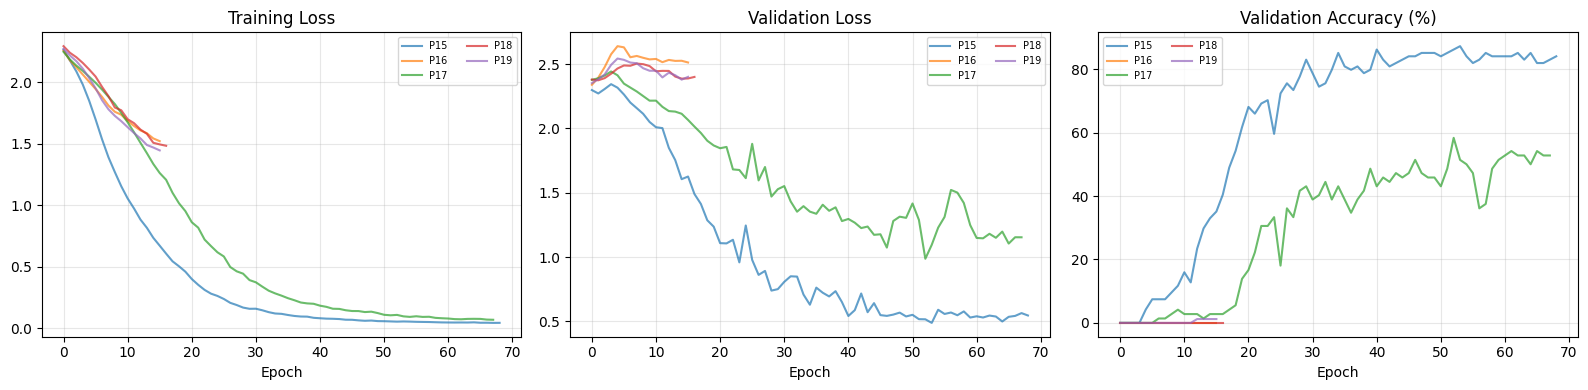

In [17]:
n_folds = len(results["histories"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, hist in enumerate(results["histories"]):
    p = results["participant"][i]
    axes[0].plot(hist["train_loss"], alpha=0.7, label=f"P{p}")
    axes[1].plot(hist["val_loss"], alpha=0.7, label=f"P{p}")
    axes[2].plot(np.array(hist["val_acc"]) * 100, alpha=0.7, label=f"P{p}")

axes[0].set_title("Training Loss")
axes[1].set_title("Validation Loss")
axes[2].set_title("Validation Accuracy (%)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


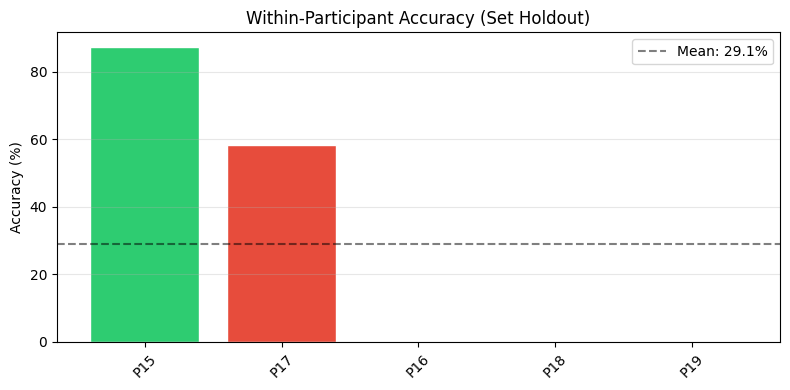

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

participants_sorted = sorted(zip(results["participant"], results["acc"]),
                             key=lambda x: x[1], reverse=True)
ps, accs = zip(*participants_sorted)
colors = ["#2ecc71" if a >= 0.8 else "#e67e22" if a >= 0.6 else "#e74c3c"
          for a in accs]

ax.bar(range(len(ps)), [a * 100 for a in accs], color=colors, edgecolor="white")
ax.set_xticks(range(len(ps)))
ax.set_xticklabels([f"P{p}" for p in ps], rotation=45)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Within-Participant Accuracy (Set Holdout)")
ax.axhline(y=np.mean(results["acc"]) * 100, color="black",
           linestyle="--", alpha=0.5, label=f"Mean: {np.mean(results['acc'])*100:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


---
## 8. Confusion Matrix (Aggregated)


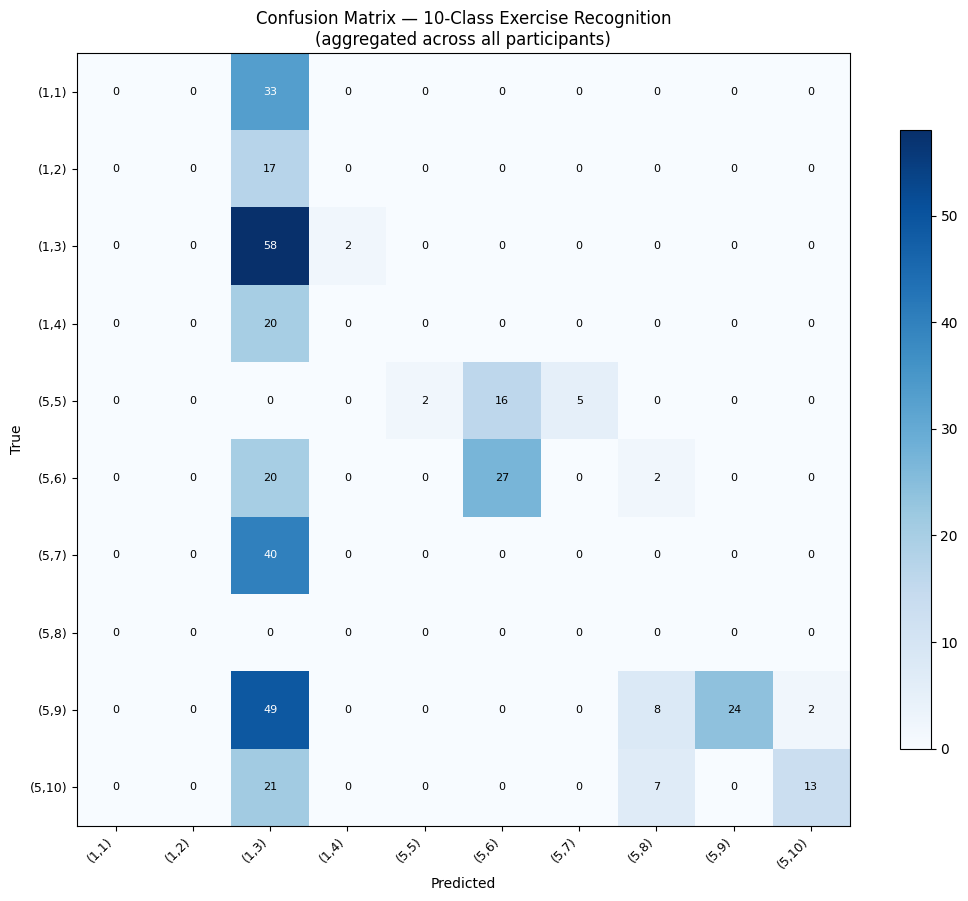


Classification Report:
              precision    recall  f1-score   support

       (1,1)     0.0000    0.0000    0.0000        33
       (1,2)     0.0000    0.0000    0.0000        17
       (1,3)     0.2248    0.9667    0.3648        60
       (1,4)     0.0000    0.0000    0.0000        20
       (5,5)     1.0000    0.0870    0.1600        23
       (5,6)     0.6279    0.5510    0.5870        49
       (5,7)     0.0000    0.0000    0.0000        40
       (5,8)     0.0000    0.0000    0.0000         0
       (5,9)     1.0000    0.2892    0.4486        83
      (5,10)     0.8667    0.3171    0.4643        41

    accuracy                         0.3388       366
   macro avg     0.3719    0.2211    0.2025       366
weighted avg     0.5076    0.3388    0.3022       366



In [19]:
all_y_true = np.array(results["all_y_true"])
all_y_pred = np.array(results["all_y_pred"])

cm = confusion_matrix(all_y_true, all_y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Confusion Matrix — 10-Class Exercise Recognition\n"
             "(aggregated across all participants)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_y_true, all_y_pred,
                            target_names=CLASS_NAMES, digits=4))


---
## 9. Per-Exercise Accuracy Chart


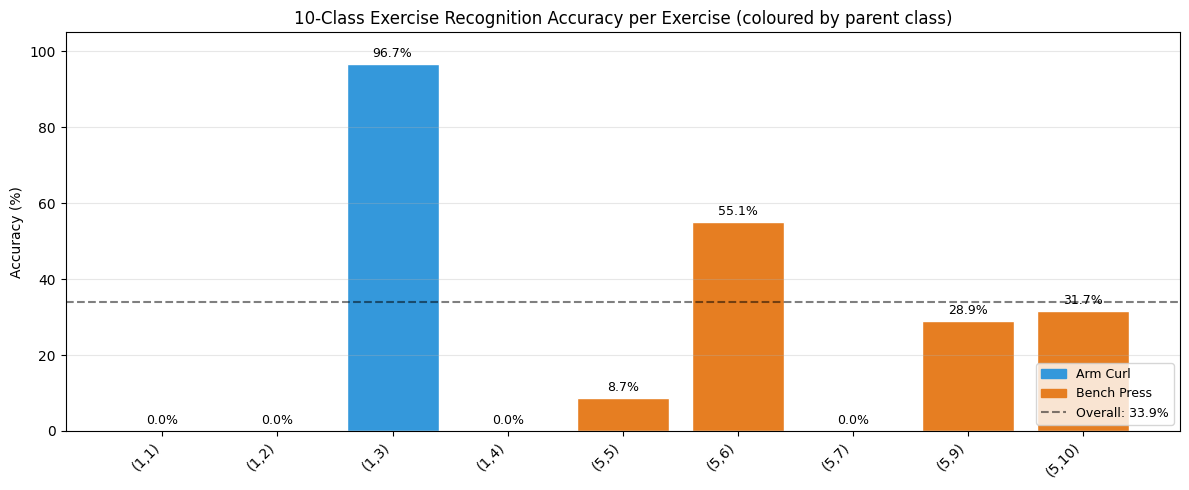

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

ex_names   = ex_df["Exercise"].tolist()
ex_accs    = ex_df["Acc (%)"].tolist()
ex_parents = ex_df["Parent Class"].tolist()

colors = ["#3498db" if p == "Arm Curl" else "#e67e22" for p in ex_parents]
bars = ax.bar(range(len(ex_names)), ex_accs, color=colors, edgecolor="white")
ax.set_xticks(range(len(ex_names)))
ax.set_xticklabels(ex_names, rotation=45, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_title("10-Class Exercise Recognition Accuracy per Exercise"
             " (coloured by parent class)")
ax.axhline(y=accuracy_score(all_y_true_arr, all_y_pred_arr) * 100,
           color="black", linestyle="--", alpha=0.5,
           label=f"Overall: {accuracy_score(all_y_true_arr, all_y_pred_arr)*100:.1f}%")
ax.set_ylim(0, 105)
for bar, acc in zip(bars, ex_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{acc:.1f}%", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#3498db", label="Arm Curl"),
    Patch(color="#e67e22", label="Bench Press"),
] + [ax.get_lines()[0]], loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


---
## 10. Save / Load Model


In [21]:
save_path = os.path.join(BASE_PATH, "cnn_lstm_within_participant_10class.pt")
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")


Model saved to: /content/drive/MyDrive/26S/Wearable Health Tech/1A Activity Recognition/Data & Code & Resources/MyoGym Model/cnn_lstm_within_participant_10class.pt


In [22]:
loaded_model = CNN_LSTM(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
).to(DEVICE)
loaded_model.load_state_dict(torch.load(save_path, map_location=DEVICE))
loaded_model.eval()

# Predict on a single validation window
sample = torch.FloatTensor(X_va[:1]).to(DEVICE)
with torch.no_grad():
    logits = loaded_model(sample)
    probs  = torch.softmax(logits, dim=1)
    pred   = logits.argmax(1).item()

p, c = LABEL_TO_PAIR[pred]
print(f"Predicted class: {pred}  ->  ({p},{c})  {PARENT_CLASSES[p]}")
print(f"\nClass probabilities:")
for name, prob in zip(CLASS_NAMES, probs[0].cpu().numpy()):
    bar = chr(9608) * int(prob * 40)
    print(f"  {name:<8s}  {prob:.4f}  {bar}")


Predicted class: 2  ->  (1,3)  Arm Curl

Class probabilities:
  (1,1)     0.0877  ███
  (1,2)     0.1006  ████
  (1,3)     0.1273  █████
  (1,4)     0.0991  ███
  (5,5)     0.0983  ███
  (5,6)     0.0913  ███
  (5,7)     0.0924  ███
  (5,8)     0.1013  ████
  (5,9)     0.1082  ████
  (5,10)    0.0939  ███
